
========== ADVANCED SALES DATA ANALYZER ==========
1. Load Dataset
2. Explore Data
3. Handle Missing Data
4. Mathematical Operations
5. Search / Sort / Filter
6. Aggregation
7. Statistical Analysis
8. Pivot Table
9. Visualization
10. Exit


Enter your choice:  1
Enter CSV file path:  sales_data.csv


✅ Dataset loaded successfully!

========== ADVANCED SALES DATA ANALYZER ==========
1. Load Dataset
2. Explore Data
3. Handle Missing Data
4. Mathematical Operations
5. Search / Sort / Filter
6. Aggregation
7. Statistical Analysis
8. Pivot Table
9. Visualization
10. Exit


Enter your choice:  9



1. Product Wise Sales (Bar)
2. Year Wise Sales (Line)
3. Sales vs Profit (Scatter)
4. Region Share (Pie)
5. Sales Distribution (Histogram)
6. Correlation Heatmap
7. Monthly Sales Trend


Enter choice:  4


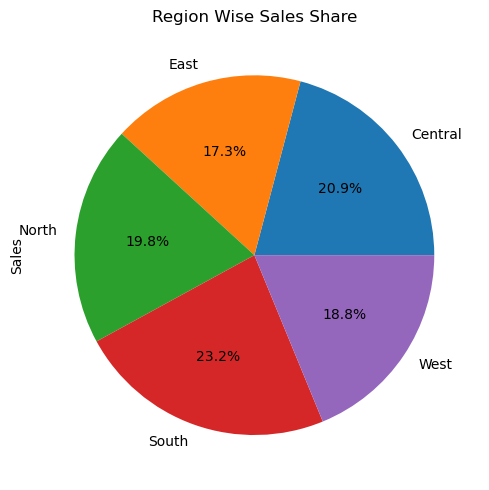


========== ADVANCED SALES DATA ANALYZER ==========
1. Load Dataset
2. Explore Data
3. Handle Missing Data
4. Mathematical Operations
5. Search / Sort / Filter
6. Aggregation
7. Statistical Analysis
8. Pivot Table
9. Visualization
10. Exit


In [ ]:
# import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


class SalesDataAnalyzer:

    def __init__(self):
        self.data = None

    def __del__(self):
        print("Program closed. Resources cleaned.")

    # ------------------ Load Data ------------------
    def load_data(self, file_path):
        try:
            self.data = pd.read_csv(file_path)
            self.data["OrderDate"] = pd.to_datetime(self.data["OrderDate"], dayfirst=True)
            print("✅ Dataset loaded successfully!")
        except Exception as e:
            print("❌ Error loading file:", e)

    # ------------------ Explore Data ------------------
    def explore_data(self):
        if self.data is None:
            print("Load dataset first!")
            return

        print("\n1. First 5 rows")
        print("2. Last 5 rows")
        print("3. Column Names")
        print("4. Data Types")
        print("5. Basic Info")
        choice = input("Enter choice: ")

        if choice == "1":
            print(self.data.head())
        elif choice == "2":
            print(self.data.tail())
        elif choice == "3":
            print(self.data.columns)
        elif choice == "4":
            print(self.data.dtypes)
        elif choice == "5":
            print(self.data.info())

    # ------------------ Handle Missing Data ------------------
    def clean_data(self):
        if self.data is None:
            return

        print(self.data.isnull().sum())
        self.data.fillna(self.data.mean(numeric_only=True), inplace=True)
        print("Missing values handled!")

    # ------------------ Mathematical Operations ------------------
    def mathematical_operations(self):
        if self.data is None:
            return

        print("\nTotal Sales:", self.data["Sales"].sum())
        print("Total Profit:", self.data["Profit"].sum())

        self.data["Profit_Percentage"] = (
            self.data["Profit"] / self.data["Sales"]) * 100

        print("\nProfit Percentage column added.")
        print(self.data.head())

    # ------------------ Search / Sort / Filter ------------------
    def search_sort_filter(self):
        if self.data is None:
            return

        print("\n1. Search by Product")
        print("2. Filter by Region")
        print("3. Filter by Category")
        print("4. Sort by Sales (Descending)")
        choice = input("Enter choice: ")

        if choice == "1":
            p = input("Enter product name: ")
            print(self.data[self.data["Product"] == p])
        elif choice == "2":
            r = input("Enter region: ")
            print(self.data[self.data["Region"] == r])
        elif choice == "3":
            c = input("Enter category: ")
            print(self.data[self.data["Category"] == c])
        elif choice == "4":
            print(self.data.sort_values("Sales", ascending=False))

    # ------------------ Aggregation ------------------
    def aggregate_functions(self):
        if self.data is None:
            return

        print("\n--- Region Wise Sales & Profit ---")
        print(self.data.groupby("Region")[["Sales", "Profit"]].sum())

        print("\n--- Category Wise Sales & Profit ---")
        print(self.data.groupby("Category")[["Sales", "Profit"]].sum())

        print("\n--- SalesPerson Performance ---")
        print(self.data.groupby("SalesPerson")[["Sales", "Profit"]].sum())

    # ------------------ Statistical Analysis ------------------
    def statistical_analysis(self):
        if self.data is None:
            return

        print(self.data.describe())

    # ------------------ Pivot Table ------------------
    def create_pivot(self):
        if self.data is None:
            return

        pivot = pd.pivot_table(
            self.data,
            values="Sales",
            index="Category",
            columns="Year",
            aggfunc="sum"
        )
        print("\nPivot Table (Category vs Year)")
        print(pivot)

    # ------------------ Visualization ------------------
    def visualize_data(self):
        if self.data is None:
            return

        print("\n1. Product Wise Sales (Bar)")
        print("2. Year Wise Sales (Line)")
        print("3. Sales vs Profit (Scatter)")
        print("4. Region Share (Pie)")
        print("5. Sales Distribution (Histogram)")
        print("6. Correlation Heatmap")
        print("7. Monthly Sales Trend")
        choice = input("Enter choice: ")

        plt.figure(figsize=(8, 5))

        if choice == "1":
            self.data.groupby("Product")["Sales"].sum().plot(kind="bar")
            plt.title("Product Wise Sales")

        elif choice == "2":
            self.data.groupby("Year")["Sales"].sum().plot(kind="line", marker="o")
            plt.title("Year Wise Sales Trend")

        elif choice == "3":
            plt.scatter(self.data["Sales"], self.data["Profit"])
            plt.xlabel("Sales")
            plt.ylabel("Profit")
            plt.title("Sales vs Profit")

        elif choice == "4":
            self.data.groupby("Region")["Sales"].sum().plot(
                kind="pie", autopct="%1.1f%%")
            plt.title("Region Wise Sales Share")

        elif choice == "5":
            plt.hist(self.data["Sales"], bins=10)
            plt.title("Sales Distribution")

        elif choice == "6":
            sns.heatmap(self.data.corr(numeric_only=True), annot=True, cmap="coolwarm")
            plt.title("Correlation Heatmap")

        elif choice == "7":
            monthly = self.data.groupby(
                self.data["OrderDate"].dt.to_period("M")
            )["Sales"].sum()
            monthly.plot(kind="line", marker="o")
            plt.title("Monthly Sales Trend")

        else:
            print("Invalid choice!")
            return

        plt.tight_layout()
        plt.show()


# ================= MAIN MENU =================

def main():
    analyzer = SalesDataAnalyzer()

    while True:
        print("\n========== ADVANCED SALES DATA ANALYZER ==========")
        print("1. Load Dataset")
        print("2. Explore Data")
        print("3. Handle Missing Data")
        print("4. Mathematical Operations")
        print("5. Search / Sort / Filter")
        print("6. Aggregation")
        print("7. Statistical Analysis")
        print("8. Pivot Table")
        print("9. Visualization")
        print("10. Exit")

        choice = input("Enter your choice: ")

        if choice == "1":
            path = input("Enter CSV file path: ")
            analyzer.load_data(path)
        elif choice == "2":
            analyzer.explore_data()
        elif choice == "3":
            analyzer.clean_data()
        elif choice == "4":
            analyzer.mathematical_operations()
        elif choice == "5":
            analyzer.search_sort_filter()
        elif choice == "6":
            analyzer.aggregate_functions()
        elif choice == "7":
            analyzer.statistical_analysis()
        elif choice == "8":
            analyzer.create_pivot()
        elif choice == "9":
            analyzer.visualize_data()
        elif choice == "10":
            print("Exiting program...")
            break
        else:
            print("Invalid choice!")


if __name__ == "__main__":
    main()
